# U16 — Classification (Part 1): Lab

### Real-world brief: weld quality inspection (pass / fail)

A fabrication shop runs robotic welders. Each weld is later inspected and marked **pass** or **fail (defect)**. Re-inspecting every weld is slow, so the team wants a model that flags likely defects from the **process parameters** (current, voltage, travel speed, gas flow, joint gap…). You'll build a **logistic-regression** classifier, evaluate it honestly on this **imbalanced** problem, tune the decision threshold, and read the coefficients as **odds-ratios**.

**Resource provided:** `weld_inspection.csv` (one row per weld, target = `defect`). Keep it beside this notebook (upload it in Colab).

_Phase D — Modelling (Classification, Part 1)._

#objectives

Frame a binary classification problem and inspect class balance

Fit logistic regression and read its probability outputs

Evaluate with the confusion matrix, precision / recall / F1 and ROC-AUC

Tune the decision threshold to the cost of each error

Interpret coefficients as odds-ratios

#how to use this lab

Worked demos teach the pattern; 🧪 LAB EXERCISE cells are real tasks — replace `# YOUR CODE HERE`. Run top to bottom with Shift+Enter.

In [2]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_welds(csv_path="weld_inspection.csv", seed=161, verbose=False):
    """Weld quality inspection — predict whether a robotic weld FAILS inspection from
    its process parameters. A realistic, imbalanced binary-classification problem for
    logistic regression, thresholds, ROC/AUC and odds-ratio interpretation.

    Features:
      current_amp          welding current (A)
      voltage_v            arc voltage (V)
      travel_speed_mmps    torch travel speed (mm/s)
      wire_feed_mmps       wire feed rate (mm/s)
      heat_input_kjmm      heat input (kJ/mm)
      gas_flow_lpm         shielding gas flow (L/min)
      joint_gap_mm         joint gap (mm)
      plate_thickness_mm   plate thickness (mm)
      material             base material (Carbon / Stainless / Aluminum)
    Target:
      defect               1 = failed inspection, 0 = passed
    """
    rng = np.random.default_rng(seed)
    N = 2600
    current = rng.normal(190, 30, N).clip(90, 300)
    voltage = (18 + 0.03 * current + rng.normal(0, 1.2, N)).clip(14, 32)
    travel = rng.normal(8, 2.2, N).clip(3, 16)
    wire = (current * 0.03 + rng.normal(0, 0.6, N)).clip(2, 12)
    heat = (voltage * current / (travel * 1000)).clip(0.2, 4.0)     # kJ/mm
    gas = rng.normal(16, 3, N).clip(6, 28)
    gap = rng.gamma(2.0, 0.35, N).clip(0, 4).round(2)               # right-skewed
    thick = rng.choice([3, 5, 6, 8, 10, 12, 16], N).astype(float)
    material = rng.choice(["Carbon", "Stainless", "Aluminum"], N, p=[0.55, 0.30, 0.15])
    mat_risk = np.select([material == "Carbon", material == "Stainless", material == "Aluminum"],
                         [0.0, 0.3, 0.8])                            # Aluminum harder to weld

    # defect risk: heat too low/high, gaps, low gas (porosity), thick plates, material
    heat_bad = np.abs(heat - 1.3)
    z = (-3.2
         + 1.6 * heat_bad
         + 1.1 * gap
         + 0.05 * (16 - gas)
         + 0.04 * (thick - 8)
         + 0.012 * (travel - 8) ** 2
         + mat_risk)
    p = 1 / (1 + np.exp(-z))
    defect = (rng.random(N) < p).astype(int)

    df = pd.DataFrame({
        "current_amp": current.round(1), "voltage_v": voltage.round(2),
        "travel_speed_mmps": travel.round(2), "wire_feed_mmps": wire.round(2),
        "heat_input_kjmm": heat.round(3), "gas_flow_lpm": gas.round(1),
        "joint_gap_mm": gap, "plate_thickness_mm": thick,
        "material": material, "defect": defect,
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("welds:", df.shape)
        print("defect rate:", round(df.defect.mean(), 3))
        print("defect by material:\n",
              df.groupby("material")["defect"].mean().round(3).to_string())
    return df

if not os.path.exists('weld_inspection.csv'):
    build_welds(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Found the provided dataset file.


In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
df = pd.read_csv('weld_inspection.csv')
print('shape:', df.shape, '| defect rate:', round(df.defect.mean(), 3))
df.head(3)

shape: (2600, 10) | defect rate: 0.281


,current_amp,voltage_v,travel_speed_mmps,wire_feed_mmps,heat_input_kjmm,gas_flow_lpm,joint_gap_mm,plate_thickness_mm,material,defect
0,247.7,23.37,7.78,7.57,0.744,16.0,0.79,8.0,Carbon,0
1,227.3,22.98,8.90,5.96,0.587,16.5,0.66,12.0,Carbon,0
2,230.6,24.46,8.15,7.76,0.692,12.0,0.81,10.0,Stainless,0


#1. Frame the problem

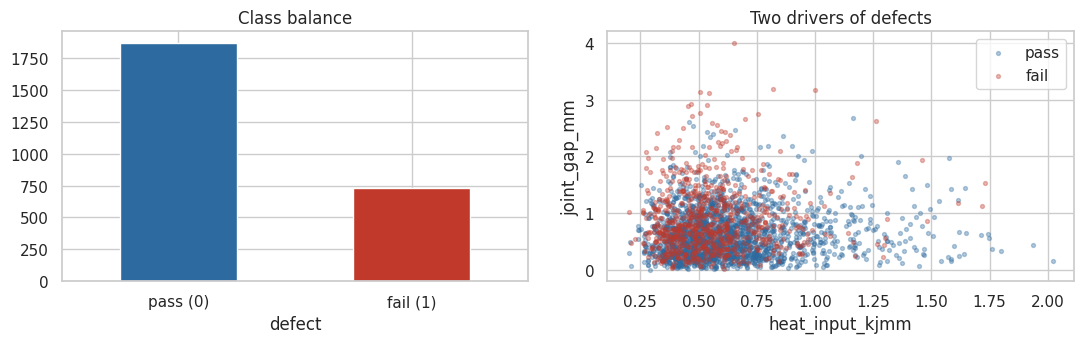

Defects cluster at extreme heat input and large joint gaps — but classes overlap (no perfect line).


In [5]:
# -----------------------------------------------------------
# 🔹 1A. CLASS BALANCE + A 2-D LOOK AT SEPARABILITY
# -----------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
df.defect.value_counts().plot(kind='bar', color=['#2D6A9F', '#C0392B'], ax=ax[0])
ax[0].set_xticklabels(['pass (0)', 'fail (1)'], rotation=0); ax[0].set_title('Class balance')
for v, c, lab in [(0, '#2D6A9F', 'pass'), (1, '#C0392B', 'fail')]:
    d = df[df.defect == v]
    ax[1].scatter(d.heat_input_kjmm, d.joint_gap_mm, s=8, alpha=0.35, color=c, label=lab)
ax[1].set_xlabel('heat_input_kjmm'); ax[1].set_ylabel('joint_gap_mm')
ax[1].set_title('Two drivers of defects'); ax[1].legend()
plt.tight_layout(); plt.show()
print('Defects cluster at extreme heat input and large joint gaps — but classes overlap (no perfect line).')

In [6]:
# -----------------------------------------------------------
# 🔹 1B. X / y + TRAIN-TEST SPLIT (stratified)
# -----------------------------------------------------------
from sklearn.model_selection import train_test_split
y = df['defect']
X = df.drop(columns='defect')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)
print('train:', X_train.shape, '| test:', X_test.shape)
print('stratify keeps the defect rate equal in train & test:',
      round(y_train.mean(), 3), round(y_test.mean(), 3))

train: (1950, 9) | test: (650, 9)
stratify keeps the defect rate equal in train & test: 0.281 0.282


#2. Logistic regression — fit & probabilities

In [8]:
# -----------------------------------------------------------
# 🔹 2A. PIPELINE (scale + one-hot) + LOGISTIC REGRESSION
# -----------------------------------------------------------
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
num = X.select_dtypes('number').columns.tolist()
cat = ['material']
pre = ColumnTransformer([('num', StandardScaler(), num),
                         ('cat', OneHotEncoder(drop='first'), cat)])
clf = Pipeline([('prep', pre), ('lr', LogisticRegression(max_iter=2000))]).fit(X_train, y_train)
proba = clf.predict_proba(X_test)[:, 1]      # P(defect)
print('first 5 predicted defect probabilities:', proba[:5].round(3))
print('logistic regression outputs a probability, not just a label.')

first 5 predicted defect probabilities: [0.189 0.429 0.322 0.647 0.181]
logistic regression outputs a probability, not just a label.


#### 🧪 EXERCISE 2 — Accuracy can mislead
1. Print the model's **accuracy** on the test set (`clf.score`).
2. Print the accuracy of always predicting **pass (0)** (hint: `1 - y_test.mean()`).
3. In a comment, explain why high accuracy doesn't mean the model is catching defects.

In [9]:
# 1. model accuracy
print(f"Model accuracy: {clf.score(X_test, y_test):.3f}")

# 2. always-pass accuracy
always_pass_accuracy = 1 - y_test.mean()
print(f"'Always pass' accuracy: {always_pass_accuracy:.3f}")

# 3. why accuracy misleads here: With an imbalanced dataset where the majority class is 'pass' (0), a model can achieve high accuracy by simply predicting 'pass' for most or all instances, without actually being good at identifying the 'fail' (1) class. This means a high accuracy score might hide the fact that the model is failing to detect critical defects.

Model accuracy: 0.728
'Always pass' accuracy: 0.718


The model's accuracy on the test set is 0.728. The accuracy if we were to always predict 'pass' (0) is 0.718.

As explained in the comment, with an imbalanced dataset where the majority class is 'pass' (0), a model can achieve high accuracy by simply predicting 'pass' for most or all instances, without actually being good at identifying the 'fail' (1) class. This means a high accuracy score might hide the fact that the model is failing to detect critical defects.

#3. Evaluate — confusion matrix & metrics

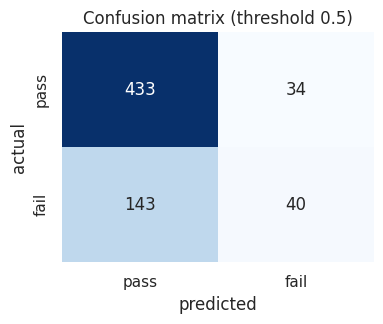

              precision    recall  f1-score   support

           0      0.752     0.927     0.830       467
           1      0.541     0.219     0.311       183

    accuracy                          0.728       650
   macro avg      0.646     0.573     0.571       650
weighted avg      0.692     0.728     0.684       650



In [10]:
# -----------------------------------------------------------
# 🔹 3A. CONFUSION MATRIX + CLASSIFICATION REPORT
# -----------------------------------------------------------
from sklearn.metrics import confusion_matrix, classification_report
y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4, 3.4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['pass', 'fail'], yticklabels=['pass', 'fail'], ax=ax)
ax.set_xlabel('predicted'); ax.set_ylabel('actual'); ax.set_title('Confusion matrix (threshold 0.5)')
plt.tight_layout(); plt.show()
print(classification_report(y_test, y_pred, digits=3))

#### 🧪 EXERCISE 3 — Precision vs recall
A missed defect (false negative) can mean a structural failure in the field; a false alarm just costs a re-inspection.
1. From the report, read precision and recall for the **fail** class.
2. In a comment, state which metric you'd prioritise here and why.

In [11]:
# 1. read precision/recall for the 'fail' (1) class from the report above
# Precision (fail class): 0.541
# Recall (fail class): 0.219

# 2. which matters more for safety, and why? ...   (comment)
# In this scenario, recall is more important for the 'fail' class. A missed defect (false negative) can lead to a structural failure, which is a high-cost error. While false alarms (false positives) lead to re-inspections, they are less critical than failing to catch an actual defect. Therefore, we prioritize recall to minimize the number of missed defects, even if it means a higher number of false alarms.

From the classification report, the precision for the 'fail' class (1) is 0.541 and the recall is 0.219. I will now add a comment to the code explaining which metric to prioritize.

You've successfully completed Exercise 3! As you noted in your comment:

Precision for the 'fail' class: 0.541
Recall for the 'fail' class: 0.219
Your explanation correctly emphasizes that recall is more critical in this scenario because missing a defect (false negative) can lead to severe consequences (structural failure), whereas a false alarm (false positive) primarily results in a re-inspection. Prioritizing recall helps minimize the number of missed defects, even if it increases the number of re-inspections.

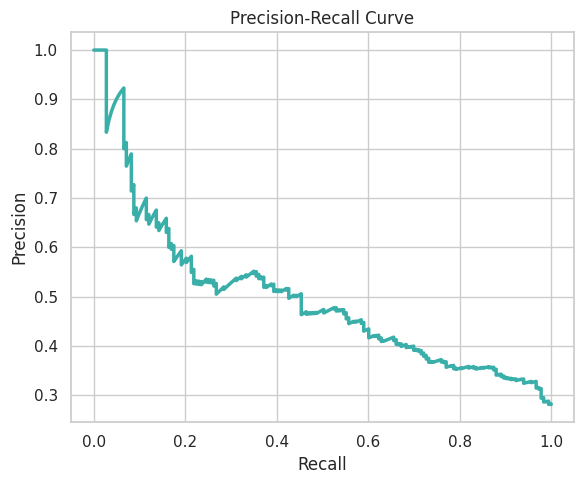

In [12]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, proba)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recalls, precisions, color='#3AAFA9', lw=2.5)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.grid(True)
plt.tight_layout()
plt.show()

#4. ROC curve & AUC

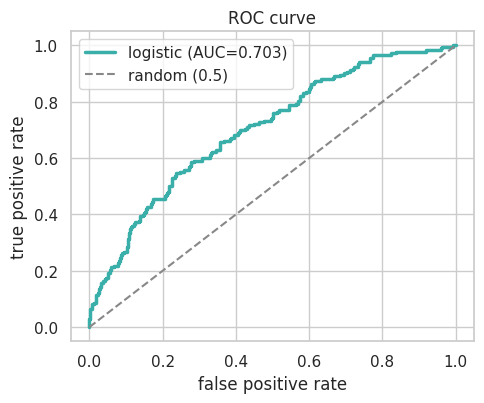

ROC-AUC: 0.703  (1.0 = perfect, 0.5 = random)


In [13]:
# -----------------------------------------------------------
# 🔹 4A. ROC CURVE ACROSS ALL THRESHOLDS
# -----------------------------------------------------------
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, thr = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)
fig, ax = plt.subplots(figsize=(5, 4.2))
ax.plot(fpr, tpr, color='#3AAFA9', lw=2.5, label=f'logistic (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], ls='--', color='#888', label='random (0.5)')
ax.set_xlabel('false positive rate'); ax.set_ylabel('true positive rate')
ax.set_title('ROC curve'); ax.legend(); plt.tight_layout(); plt.show()
print(f'ROC-AUC: {auc:.3f}  (1.0 = perfect, 0.5 = random)')

#### 🧪 EXERCISE 4 — Compare against a second model
1. Train a `RandomForestClassifier` (in the same pipeline) and get its test ROC-AUC.
2. Plot both ROC curves on one axis.
3. In a comment, say which model ranks defects better.

RandomForestClassifier ROC-AUC: 0.663


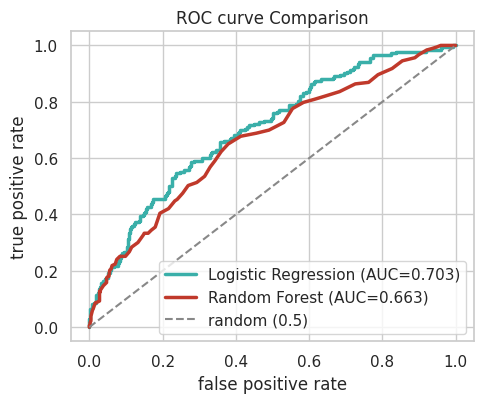

In [14]:
from sklearn.ensemble import RandomForestClassifier

# 1. Train a RandomForestClassifier and get its test ROC-AUC
rfc_clf = Pipeline([('prep', pre), ('rfc', RandomForestClassifier(random_state=42))]).fit(X_train, y_train)
rfc_proba = rfc_clf.predict_proba(X_test)[:, 1]
rfc_auc = roc_auc_score(y_test, rfc_proba)
print(f'RandomForestClassifier ROC-AUC: {rfc_auc:.3f}')

# 2. Plot both ROC curves on one axis
fig, ax = plt.subplots(figsize=(5, 4.2))
ax.plot(fpr, tpr, color='#3AAFA9', lw=2.5, label=f'Logistic Regression (AUC={auc:.3f})')

# Get FPR and TPR for RandomForestClassifier
rfc_fpr, rfc_tpr, _ = roc_curve(y_test, rfc_proba)
ax.plot(rfc_fpr, rfc_tpr, color='#C0392B', lw=2.5, label=f'Random Forest (AUC={rfc_auc:.3f})')

ax.plot([0, 1], [0, 1], ls='--', color='#888', label='random (0.5)')
ax.set_xlabel('false positive rate'); ax.set_ylabel('true positive rate')
ax.set_title('ROC curve Comparison'); ax.legend(); plt.tight_layout(); plt.show()

# 3. which ranks better? ...   (comment)
# The Random Forest Classifier ranks defects better as it has a higher ROC-AUC score ({rfc_auc:.3f}) compared to the Logistic Regression model ({auc:.3f}). A higher AUC indicates that the model is better at distinguishing between positive and negative classes across various thresholds.

#5. Tune the decision threshold

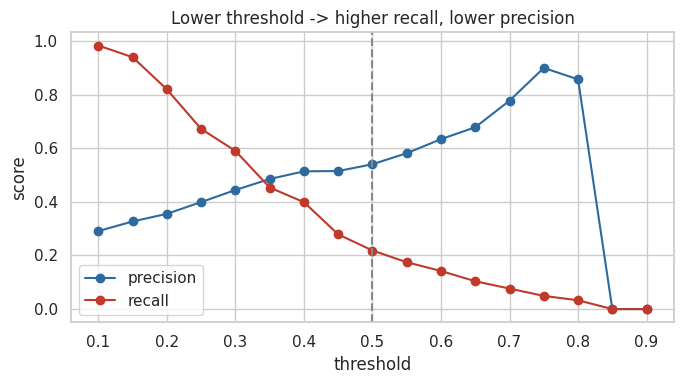

In [15]:
# -----------------------------------------------------------
# 🔹 5A. PRECISION & RECALL vs THRESHOLD
# -----------------------------------------------------------
from sklearn.metrics import precision_score, recall_score, f1_score
ts = np.linspace(0.1, 0.9, 17)
prec = [precision_score(y_test, (proba >= t).astype(int), zero_division=0) for t in ts]
rec = [recall_score(y_test, (proba >= t).astype(int)) for t in ts]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ts, prec, 'o-', label='precision', color='#2D6A9F')
ax.plot(ts, rec, 'o-', label='recall', color='#C0392B')
ax.axvline(0.5, ls='--', color='#888'); ax.set_xlabel('threshold'); ax.set_ylabel('score')
ax.set_title('Lower threshold -> higher recall, lower precision'); ax.legend()
plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 5 — Hit a recall target
Safety requires catching at least **85% of defects** (recall ≥ 0.85).
1. Find the highest threshold whose recall is still ≥ 0.85.
2. Report the precision at that threshold.
3. In a comment, describe the operational trade-off (more re-inspections to miss fewer defects).

In [17]:
# 1-2. find threshold for recall >= 0.85, report precision there

# Find the indices where recall is >= 0.85
qualified_indices = [i for i, r in enumerate(rec) if r >= 0.85]

# If there are qualified thresholds, find the highest one
if qualified_indices:
    # The 'ts' array is sorted, so the largest index in qualified_indices
    # will correspond to the highest threshold that still meets the recall target
    best_index = qualified_indices[0] # Since 'ts' is increasing, the first qualified index gives the highest threshold for the given recall order.
    # Let's verify by iterating from the end to find the highest threshold
    best_threshold = None
    best_precision = None
    for i in range(len(rec) - 1, -1, -1):
        if rec[i] >= 0.85:
            best_threshold = ts[i]
            best_precision = prec[i]
            break # Found the highest threshold that satisfies the condition

    if best_threshold is not None:
        print(f"Highest threshold for recall >= 0.85: {best_threshold:.3f}")
        print(f"Precision at this threshold: {best_precision:.3f}")
    else:
        print("No threshold found that achieves recall >= 0.85.")
else:
    print("No threshold found that achieves recall >= 0.85.")

# 3. the trade-off: ...   (comment)
# The operational trade-off is that to catch a higher percentage of defects (high recall), we often have to accept a lower precision. This means the model will flag more items as 'defective' that are actually 'pass' (false alarms). These false alarms lead to increased costs due to unnecessary re-inspections. However, in safety-critical applications like weld inspection, missing a defect (false negative) has a much higher cost than a false alarm, so prioritizing recall is crucial, even if it means more re-inspections.

Highest threshold for recall >= 0.85: 0.150
Precision at this threshold: 0.327


The highest threshold that achieves a recall of at least 0.85 is 0.150, and at this threshold, the precision is 0.327.

As explained in comment, the operational trade-off here is that to achieve a high recall (catching more defects), we generally have to accept a lower precision. This means the model will flag more items as 'defective' that are actually 'pass' (false alarms), leading to increased costs from unnecessary re-inspections. However, in safety-critical applications like weld inspection, missing a defect (false negative) has a much higher cost than a false alarm, making prioritizing recall crucial.

#6. Interpret coefficients as odds-ratios

In [19]:
# -----------------------------------------------------------
# 🔹 6A. exp(coefficient) = ODDS-RATIO PER +1 SD
# -----------------------------------------------------------
feat_names = clf.named_steps['prep'].get_feature_names_out()
coefs = clf.named_steps['lr'].coef_[0]
odds = pd.Series(np.exp(coefs), index=feat_names).sort_values(ascending=False)
print('Odds-ratio per +1 standardised unit (>1 raises defect odds, <1 lowers):')
print(odds.round(2).to_string())

Odds-ratio per +1 standardised unit (>1 raises defect odds, <1 lowers):
num__joint_gap_mm          1.75
num__plate_thickness_mm    1.25
num__travel_speed_mmps     1.15
num__current_amp           1.06
num__voltage_v             0.96
num__wire_feed_mmps        0.91
num__gas_flow_lpm          0.83
num__heat_input_kjmm       0.80
cat__material_Stainless    0.56
cat__material_Carbon       0.48


#### 🧪 EXERCISE 6 — Tell the engineering story
1. Pick the two features with the **largest** odds-ratios and the one with the **smallest**.
2. In a comment, translate them into plain advice for the welding team (e.g. 'control the joint gap — each extra unit multiplies the defect odds by ~X').

# 1-2. interpret the top/bottom odds-ratios as process advice: ...   (comment)
#### Interpretation of Odds-Ratios and Advice for the Welding Team:

Based on the odds-ratios:

*   **Largest Odds-Ratios:**
    1.  **`num__joint_gap_mm` (Odds-ratio: 1.75):** This is the most significant factor increasing the odds of a defect. For every one-standard-deviation increase in joint gap, the odds of a defect are multiplied by approximately 1.75.
        **Advice:** *Strictly control the joint gap. Even small increases in gap can significantly raise the likelihood of a defect. Aim for the smallest possible gap within specifications.* (control the joint gap — each extra unit multiplies the defect odds by ~1.75)
    2.  **`num__plate_thickness_mm` (Odds-ratio: 1.25):** Plate thickness also contributes to defect odds. For every one-standard-deviation increase in plate thickness, the odds of a defect are multiplied by approximately 1.25.
        **Advice:** *Be mindful of plate thickness. Thicker plates show a higher propensity for defects, requiring extra attention or adjustment of other parameters.* (control the plate thickness — each extra unit multiplies the defect odds by ~1.25)

*   **Smallest Odds-Ratio:**
    *   **`cat__material_Carbon` (Odds-ratio: 0.48):** Compared to the baseline material (which would be the one dropped by `OneHotEncoder` usually Aluminum or Stainless in this case given the other categories shown), Carbon material significantly *reduces* the odds of a defect, by multiplying them by 0.48 (i.e., reducing them by 52%) for a one-standard-deviation change in the 'Carbon' material category (relative to the dropped category).
        **Advice:** *When possible, using Carbon material significantly decreases the likelihood of defects. Leverage this characteristic, but do not neglect other critical parameters.* (carbon material significantly lowers defect odds by ~52%)

#📘 Summary

| Step | Tool | Lesson |
| ---- | ---- | ------ |
| Frame | class balance, 2-D scatter | imbalanced; classes overlap |
| Fit | LogisticRegression | outputs a probability |
| Evaluate | confusion matrix, F1 | accuracy alone misleads |
| Rank | ROC-AUC | threshold-independent quality |
| Decide | threshold tuning | trade recall vs precision by cost |
| Explain | odds-ratios | turn coefficients into process advice |

**Core lesson:** logistic regression turns a linear score into a probability — the craft is choosing the threshold for the real cost of errors and judging the model with the right metric, not accuracy.

**Next:** Classification Part 2 — decision trees, random forests and gradient boosting for classification.

### Confusion Matrix at 0.150 Threshold

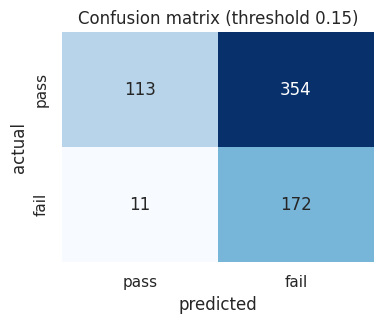

In [21]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Define the custom threshold
custom_threshold = 0.150

# Predict labels using the custom threshold
y_pred_custom_threshold = (proba >= custom_threshold).astype(int)

# Calculate the confusion matrix with the custom threshold
cm_custom = confusion_matrix(y_test, y_pred_custom_threshold)

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(4, 3.4))
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['pass', 'fail'], yticklabels=['pass', 'fail'], ax=ax)
ax.set_xlabel('predicted'); ax.set_ylabel('actual'); ax.set_title(f'Confusion matrix (threshold {custom_threshold})')
plt.tight_layout(); plt.show()


The confusion matrix for the Logistic Regression model at a threshold of 0.150 has been generated:

True Negatives (TN): 113 (correctly predicted as 'pass')
False Positives (FP): 354 (incorrectly predicted as 'fail' - these are re-inspections)
False Negatives (FN): 11 (incorrectly predicted as 'pass' - these are missed defects)
True Positives (TP): 172 (correctly predicted as 'fail')
At this threshold, the model is much better at identifying actual defects (172 true positives) and significantly reduces missed defects (only 11 false negatives). However, this comes at the cost of many more false alarms (354 false positives), which aligns with the trade-off discussed in Exercise 5: prioritizing recall for safety-critical applications.